 
# Theory

### Wolff Cluster Alogrithm
1. Randomly choose a site, the speed spin
2. If a neighbouring spin is pointing in the same direction as the speed spin, add them to our cluster $\mathfrak{C}$ with probability $P_\text{add}=1-e^{-2\beta J}$ 
3. In each we added repeat step 2, until there are no neighbouring spins left to be considered for inclusion in $\mathfrak{C}$ 
4. Flip the Cluster $\mathfrak{C}$

# Implementation

### Imports

In [33]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from numba import njit

### Ising energy

In [43]:
def energy(s, J, h):
    #2D Ising energy with periodic boundary conditions.
    
    E = 0.0
    N = s.shape[0]

    for i in range(N):
        for j in range(N):
            E -= J * s[i, j] * (
                s[(i + 1) % N, j] +
                s[i, (j + 1) % N]
            )
            E -= h * s[i, j]

    return E

### Wolff

In [3]:
def simulate_wolff(L, beta, num_steps=1000):
    spins = np.random.choice([-1,1], size=(L,L))
    for _ in range(num_steps):
        wolff_step(spins, beta)
    return spins

def wolff_step(spins,beta, record_history=False):
    J=1
    Lx,Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=bool)
    
    # (step 1) random seed spin
    x0 = np.random.randint(0, Lx)
    y0 = np.random.randint(0, Ly)
    seed_spin = spins[x0, y0]
    cluster = [(x0, y0)]
    checked[x0, y0] = True
    
    # probability add
    Padd= 1 - np.exp(-2*beta*J)
    
    history = []                      # list to hold snapshots
    if record_history:
        history.append(checked.copy())   # capture initial state (just the seed)

    
    # (step 2) build the cluster
    while cluster: # equiv to while len(cluster)>0
        i, j = cluster.pop() 
        ''' pop takes the last elemnet out of cluster (the seed spin)
            and returns its coordinates (i,j)
        '''
        for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
            ni, nj = (i + di)% Lx, (j + dj)% Ly
        
            if not checked[ni, nj] and spins[ni, nj] == seed_spin: # and check new state matched seed 
                if np.random.rand() < Padd:
                    cluster.append((ni,nj))
                    checked[ni,nj]= True
        if record_history:
            history.append(checked.copy())
   
   # (step 3) flip the cluster 
    for i, j in np.argwhere(checked):
        spins[i,j]*= -1 # flip spin in cluster
    
    '''   equivalent
    for i in range(Lx):
        for j in range(Ly):
            if checked[i,j]:
                spins[i,j]*= -1
    '''     
    if record_history:
        return spins, history
    return spins
    

#### wolff with njit 
We need to simplify the syntax for njit to work

In [4]:
@njit
def wolff_step_numba(spins, beta):
    J = 1.0
    Lx, Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=np.bool_)

    i0 = np.random.randint(0, Lx)
    j0 = np.random.randint(0, Ly)
    seed_spin = spins[i0, j0]

    # manual stack using preallocated arrays (max possible size = Lx*Ly)
    stack_i = np.empty(Lx * Ly, dtype=np.int64)
    stack_j = np.empty(Lx * Ly, dtype=np.int64)
    stack_i[0] = i0
    stack_j[0] = j0
    stack_size = 1
    checked[i0, j0] = True

    p_add = 1 - np.exp(-2 * beta * J)

    di_list = np.array([-1, 1, 0, 0])
    dj_list = np.array([0, 0, -1, 1])

    while stack_size > 0:
        stack_size -= 1
        i = stack_i[stack_size]
        j = stack_j[stack_size]

        for k in range(4):
            ni = (i + di_list[k]) % Lx
            nj = (j + dj_list[k]) % Ly
            if not checked[ni, nj] and spins[ni, nj] == seed_spin:
                if np.random.random() < p_add:
                    checked[ni, nj] = True
                    stack_i[stack_size] = ni
                    stack_j[stack_size] = nj
                    stack_size += 1

    for i in range(Lx):
        for j in range(Ly):
            if checked[i, j]:
                spins[i, j] *= -1

    return spins


@njit
def simulate_wolff_numba(L, beta, num_steps=1000):
    spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
    for _ in range(num_steps):
        wolff_step_numba(spins, beta)
    return spins

### Animations 
we want to show cluster growth around $T_c$

In [5]:
Tc = 2.26918531421
betac= 1/Tc
print(betac)

0.4406867935103584


#### cluster growth

In [ ]:
L=100
beta=0.7


spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
for _ in range(1000):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
_, history = wolff_step(spins, beta, record_history=True)
print("history")

fig, ax = plt.subplots()
im = ax.imshow(history[0], cmap="gray", vmin=0, vmax=1)
ax.axis("off")

def update(frame):
    im.set_data(history[frame])
    ax.set_title(rf"Cluster growth: step {frame}/{len(history)-1} with $\beta=${beta}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100, blit=False)
ani.save(f"plots/cluster_growth/wolff_cluster_growth_{L}x{L}_and_beta{beta}.gif", writer="pillow", fps=10)
plt.close(fig)

equilibrated
history


We see at $0.50\approx\beta>\beta_c\approx 0.44$ which means $T<T_c$ and we have a well ordered state and clusters can contain the majority if not all states.

Whereas, $0.40\approx\beta<\beta_c\approx 0.44$ which means $T>T_c$, we have disordered states and clusters form pockects in the lattice.


#### growth over spin state


In [16]:
def make_frame(spins, checked):
    """
    spins: 2D array of +1/-1
    checked: 2D boolean array (True = part of cluster so far)
    Returns an (Lx, Ly, 3) RGB image:
        spin == +1  -> light gray
        spin == -1  -> black
        checked     -> white (overrides spin color)
    """
    Lx, Ly = spins.shape
    img = np.zeros((Lx, Ly, 3))  # start black

    # spin == +1 -> gray
    img[spins == 1] = [0.7, 0.7, 0.7]
    # spin == -1 -> black (already default, but explicit for clarity)
    img[spins == -1] = [0.0, 0.0, 0.0]

    # cluster sites -> purle, overriding whatever was set above
    img[checked] = [0.65, 0.0, 1.0]

    return img

In [ ]:
def wolff_step_with_history(spins, beta):
    J = 1.0
    Lx, Ly = spins.shape
    checked = np.zeros((Lx, Ly), dtype=bool)

    i0 = np.random.randint(0, Lx)
    j0 = np.random.randint(0, Ly)
    seed_spin = spins[i0, j0]
    cluster = [(i0, j0)]
    checked[i0, j0] = True

    p_add = 1 - np.exp(-2 * beta * J)

    history = [make_frame(spins, checked)]   # composite frame, not just checked

    while cluster:
        i, j = cluster.pop()
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            ni = (i + di) % Lx
            nj = (j + dj) % Ly
            if not checked[ni, nj] and spins[ni, nj] == seed_spin:
                if np.random.random() < p_add:
                    checked[ni, nj] = True
                    cluster.append((ni, nj))
        history.append(make_frame(spins, checked))   # composite frame each step

    for i, j in np.argwhere(checked):
        spins[i, j] *= -1

    return spins, history

In [ ]:
L=100
beta=0.49

spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)
for _ in range(200):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
_, history = wolff_step_with_history(spins, beta)
print("history")

equilibrated
history


In [32]:
fig, ax = plt.subplots()
im = ax.imshow(history[0])   # no cmap needed — already RGB
ax.axis("off")

def update(frame):
    im.set_data(history[frame])
    ax.set_title(rf"Cluster growth: step {frame}/{len(history)-1} with $\beta=${beta}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(history), interval=100, blit=False)
ani.save(f"plots/growth_plus_seed/wolff_growth_{L}x{L}_beta{beta}.gif", writer="pillow", fps=10)
plt.close(fig)

## Sampling 2D lattice with the Wolff Algorithm


In [60]:
L=100
beta=0.50

spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)

#warmup
for _ in range(1):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
#warmup
energies=[]
mags=[]
for _ in range(1000):
    spins =wolff_step_numba(spins, beta)
    
    e = energy(spins, J=1, h=0)
    energies.append(e)
    mags.append(np.abs(spins.sum()))
    
    
print([round(float(e), 2) for e in energies])
print([round(float(m), 2) for m in mags])


equilibrated
[-124.0, -132.0, -136.0, -164.0, -192.0, -212.0, -216.0, -256.0, -264.0, -268.0, -280.0, -296.0, -316.0, -320.0, -328.0, -340.0, -372.0, -400.0, -404.0, -424.0, -456.0, -456.0, -464.0, -484.0, -512.0, -528.0, -576.0, -580.0, -620.0, -628.0, -628.0, -640.0, -656.0, -736.0, -760.0, -756.0, -776.0, -780.0, -796.0, -804.0, -832.0, -844.0, -848.0, -852.0, -856.0, -860.0, -876.0, -876.0, -896.0, -968.0, -972.0, -976.0, -980.0, -1012.0, -1020.0, -1048.0, -1052.0, -1068.0, -1100.0, -1168.0, -1176.0, -1212.0, -1268.0, -1316.0, -1336.0, -1344.0, -1344.0, -1388.0, -1404.0, -1408.0, -1412.0, -1424.0, -1528.0, -1580.0, -1584.0, -1584.0, -1588.0, -1620.0, -1624.0, -1668.0, -1716.0, -1724.0, -1728.0, -1732.0, -1744.0, -1760.0, -1764.0, -1800.0, -1840.0, -1840.0, -1852.0, -1864.0, -1864.0, -1864.0, -1872.0, -1880.0, -1920.0, -1924.0, -1964.0, -2036.0, -2032.0, -2036.0, -2040.0, -2052.0, -2060.0, -2064.0, -2080.0, -2088.0, -2128.0, -2244.0, -2300.0, -2312.0, -2316.0, -2360.0, -2448.0, -245

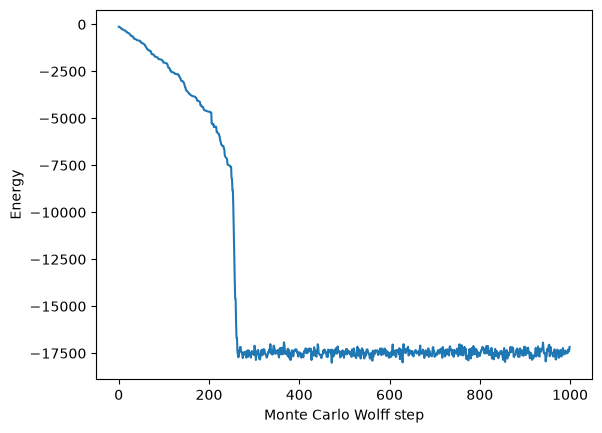

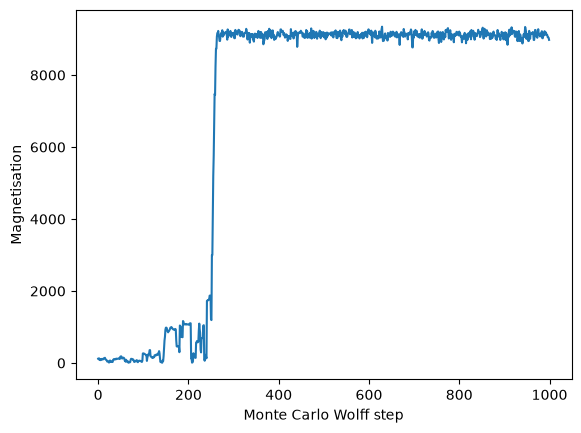

In [61]:
plt.plot(energies)
plt.xlabel("Monte Carlo Wolff step")
plt.ylabel("Energy")
plt.show()

plt.plot(mags)
plt.xlabel("Monte Carlo Wolff step")
plt.ylabel("Magnetisation")
plt.show()

In [66]:
L=100
beta=0.50

spins = np.random.choice(np.array([-1, 1]), size=(L, L)).astype(np.float64)

#warmup
for _ in range(500):
    wolff_step_numba(spins, beta)
    
print("equilibrated")
#warmup
energies=[]
mags=[]
for _ in range(1000):
    spins =wolff_step_numba(spins, beta)
    
    e = energy(spins, J=1, h=0)
    energies.append(e)
    mags.append(np.abs(spins.sum()))
    

equilibrated


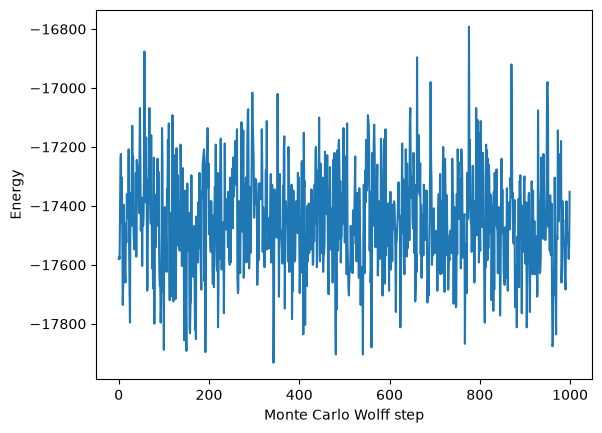

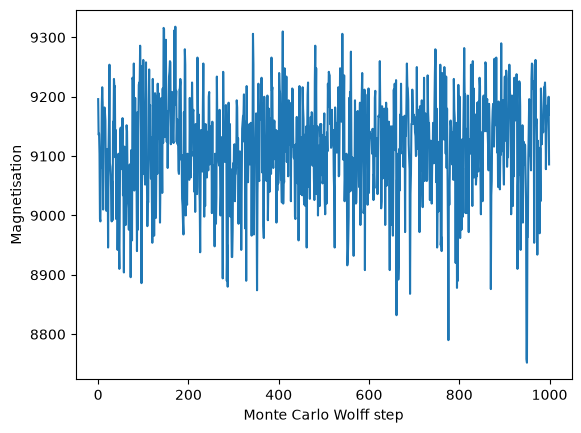

In [ ]:
plt.plot(energies)
plt.xlabel("Monte Carlo Wolff step")
plt.ylabel("Energy")
plt.show()

plt.plot(mags)
plt.xlabel("Monte Carlo Wolff step")
plt.ylabel("Magnetisation")
plt.show()

Next, we made a function that takes in a few paramters for runs and produces a plot of 4 parameters

In [88]:
def wolff_sim(L=10, temps=None, J=1.0, h=0.0,
              warmup=400, size_of_samples=1000, n_runs=5):

    Nsize = L
    Nspins = L * L

    if temps is None:
        temps = np.linspace(1.8, 2.8, 40)

    Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))
    print("Critical temp")
    print(Tc)

    E_mean, E_std = [], []
    cv_mean, cv_std = [], []
    m_mean, m_std = [], []
    chi_mean, chi_std = [], []

    for T in temps:

        beta = 1.0 / T # boltzmann constant =1 

        ###
                    
        print("Checking our warmup paramters make sense")
        print(f"At T= {T}, we have {warmup}")

        WARMUPspins = np.random.choice(
                        np.array([-1, 1]), size=(L, L)
                    ).astype(np.float64)
        
        WARMUPenergies=[]
        WARMUPmags=[]
        for _ in range(1000):
            spins =wolff_step_numba(WARMUPspins, beta)
            
            e = energy(WARMUPspins, J=1, h=0)
            WARMUPenergies.append(e)
            WARMUPmags.append(np.abs(WARMUPspins.sum())) 
                    
        plt.plot(WARMUPenergies)
        plt.xlabel("Monte Carlo Wolff step")
        plt.ylabel("Energy")
        plt.show()
        
        plt.plot(WARMUPmags)
        plt.xlabel("Monte Carlo Wolff step")
        plt.ylabel("Magnetisation")
        plt.show()


        Es, cvs, ms, chis = [], [], [], []

        for _ in range(n_runs):

            spins = np.random.choice(
                np.array([-1, 1]), size=(L, L)
            ).astype(np.float64)

            # warmup
            for _ in range(warmup):
                spins = wolff_step_numba(spins, beta)

            energies = []
            mags = []

            for _ in range(size_of_samples):
                spins = wolff_step_numba(spins, beta)

                e = energy(spins, J=J, h=h) / Nspins
                energies.append(e)
                mags.append(spins.sum())
            
            E = np.mean(energies)
            Es.append(E)

            cv = np.var(energies) * Nspins / (T ** 2)
            cvs.append(cv)

            m = np.mean(np.abs(mags)) / Nspins
            ms.append(m)

            chi = np.var(mags) / (T * Nspins)
            chis.append(chi)

        E_mean.append(np.mean(Es))
        E_std.append(np.std(Es))

        cv_mean.append(np.mean(cvs))
        cv_std.append(np.std(cvs))

        m_mean.append(np.mean(ms))
        m_std.append(np.std(ms))

        chi_mean.append(np.mean(chis))
        chi_std.append(np.std(chis))

        print(f"T={T:.3f} done, ran {n_runs} runs x {size_of_samples} samples")

    fig, ax = plt.subplots(2, 2, figsize=(10, 10))

    ax[0, 0].errorbar(temps, m_mean, yerr=m_std, fmt='o', color='red', capsize=3)
    ax[0, 0].axvline(Tc, color='green', linestyle='-', label=fr"$T_c={Tc:.2f}$")
    ax[0, 0].set_title("Magnetism")
    ax[0, 0].set_xlabel("T")
    ax[0, 0].set_ylabel("Magnetism")

    ax[1, 0].errorbar(temps, cv_mean, yerr=cv_std, fmt='o', color='blue', capsize=3)
    ax[1, 0].axvline(Tc, color='green', linestyle='-', label=fr"$T_c={Tc:.2f}$")
    ax[1, 0].set_title(r"$c_v$ vs T")
    ax[1, 0].set_xlabel("T")
    ax[1, 0].set_ylabel(r"$c_v$")

    ax[0, 1].errorbar(temps, chi_mean, yerr=chi_std, fmt='o', color='purple', capsize=3)
    ax[0, 1].axvline(Tc, color='green', linestyle='-', label=fr"$T_c={Tc:.2f}$")
    ax[0, 1].set_title("Susceptibility")
    ax[0, 1].set_xlabel("T")
    ax[0, 1].set_ylabel("Susceptibility")

    ax[1, 1].errorbar(temps, E_mean, yerr=E_std, fmt='o', color='orange', capsize=3)
    ax[1, 1].axvline(Tc, color='green', linestyle='-', label=fr"$T_c={Tc:.2f}$")
    ax[1, 1].set_title("Energy per spin")
    ax[1, 1].set_xlabel("T")
    ax[1, 1].set_ylabel("Energy per spin")

    plt.tight_layout()
    plt.savefig(f"plots/observables/observables_L{L}_sample{size_of_samples}_warmup{n_runs}.pdf")
    plt.show()

    return dict(temps=temps, E_mean=E_mean, E_std=E_std,
                cv_mean=cv_mean, cv_std=cv_std,
                m_mean=m_mean, m_std=m_std,
                chi_mean=chi_mean, chi_std=chi_std)



Critical temp
2.269185314213022
Checking our warmup paramters make sense
At T= 1.8, we have 400


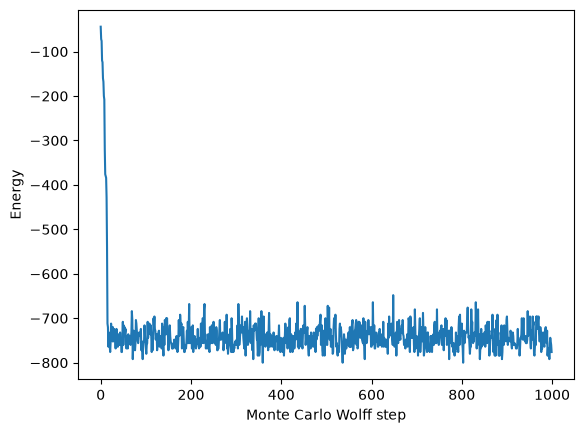

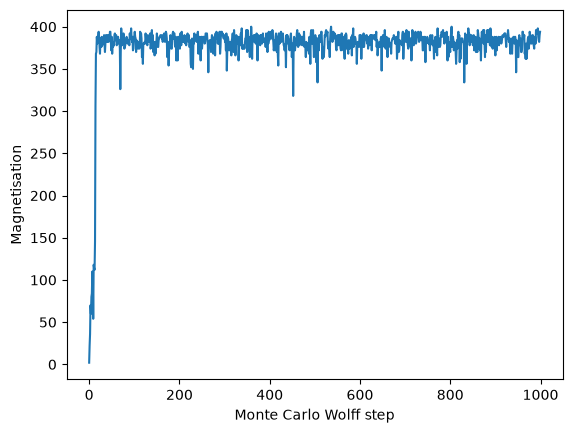

T=1.800 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.8256410256410256, we have 400


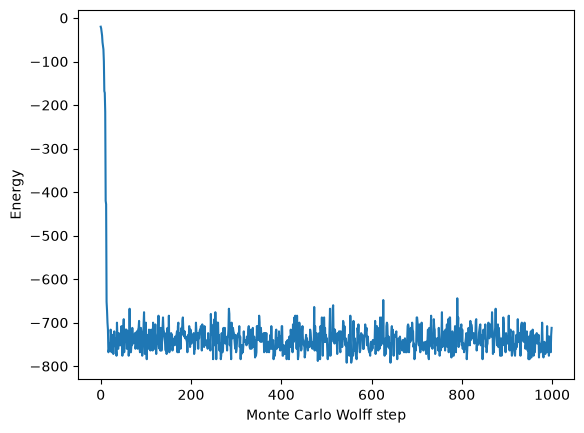

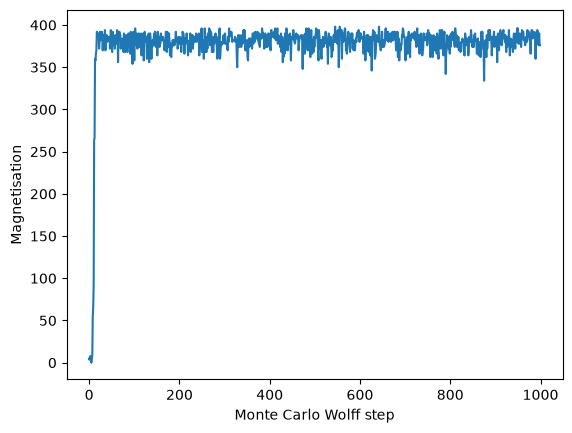

T=1.826 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.8512820512820514, we have 400


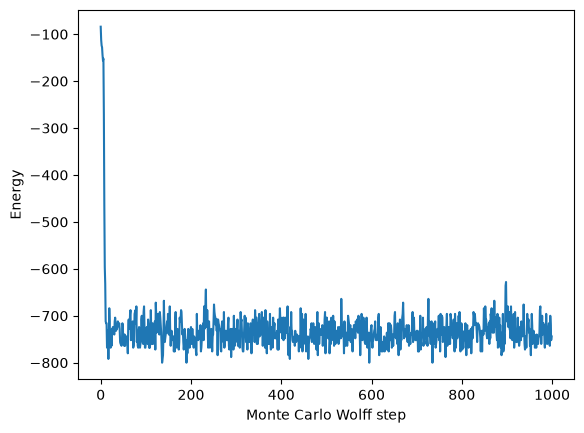

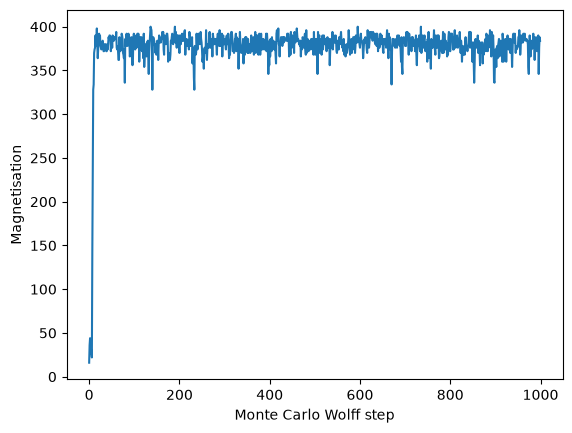

T=1.851 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.876923076923077, we have 400


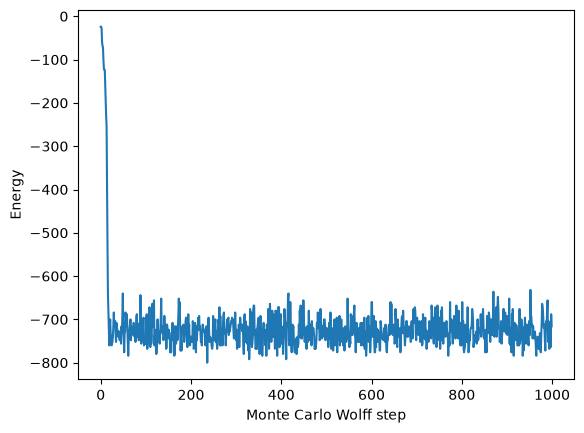

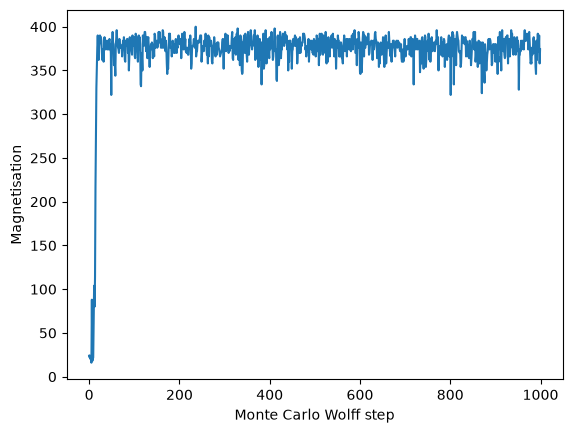

T=1.877 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.9025641025641027, we have 400


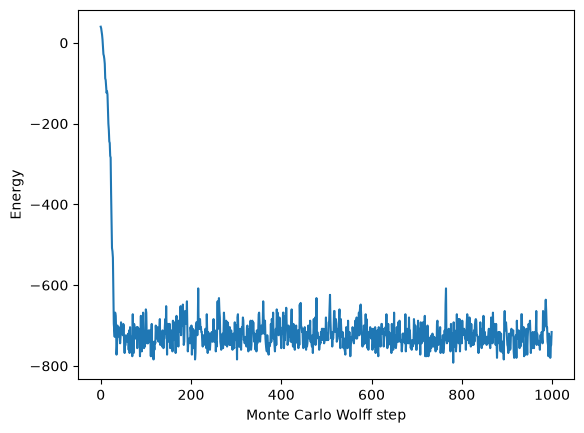

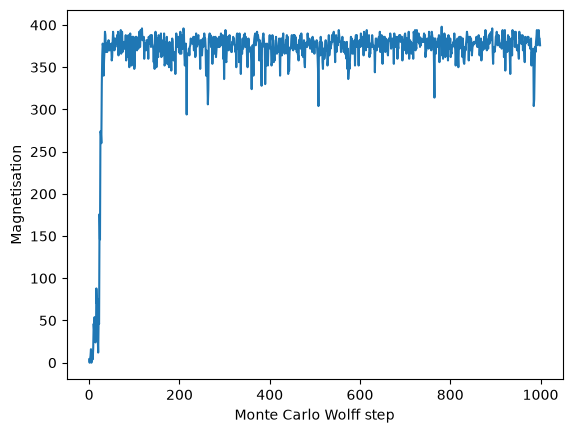

T=1.903 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.9282051282051282, we have 400


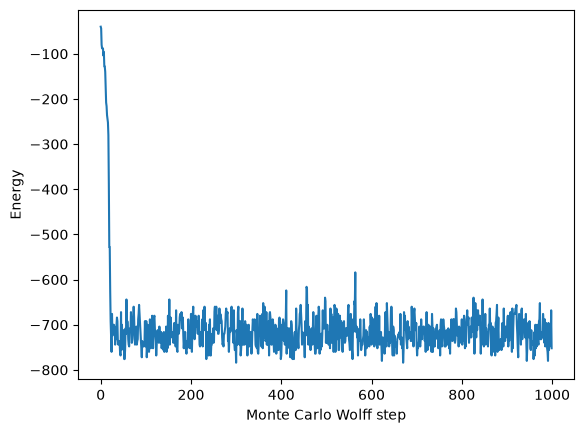

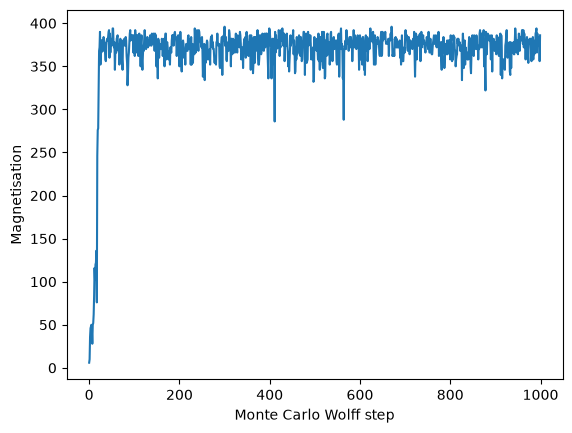

T=1.928 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.9538461538461538, we have 400


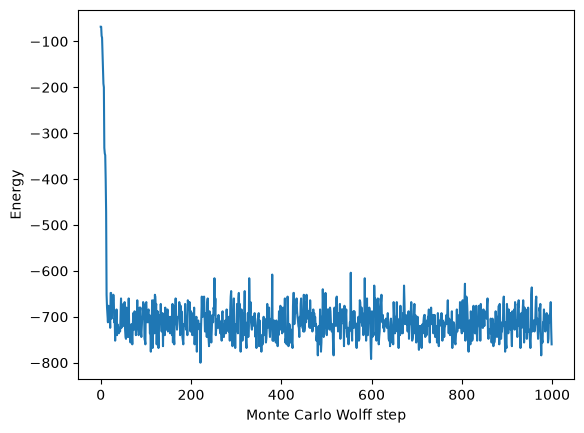

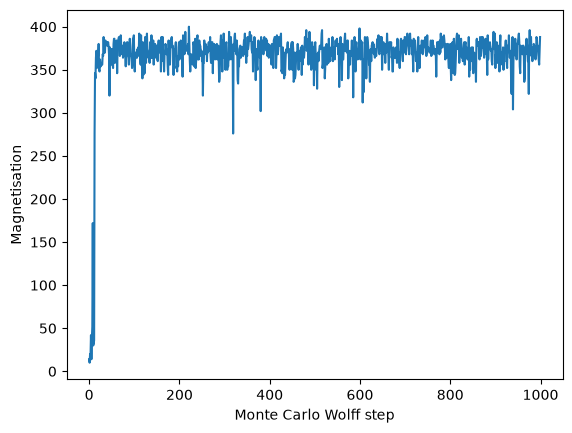

T=1.954 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 1.9794871794871796, we have 400


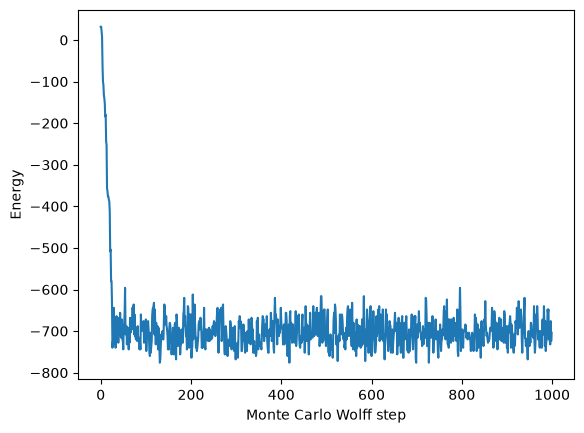

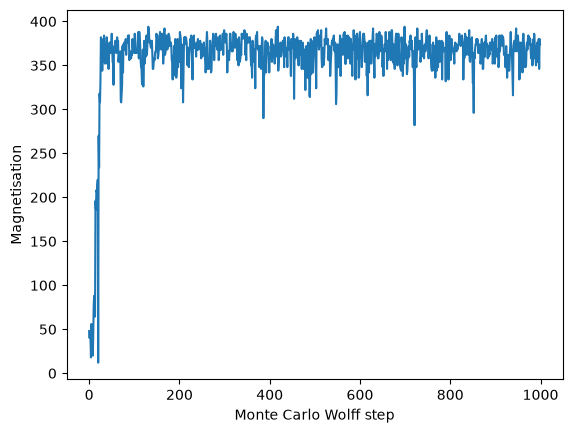

T=1.979 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.005128205128205, we have 400


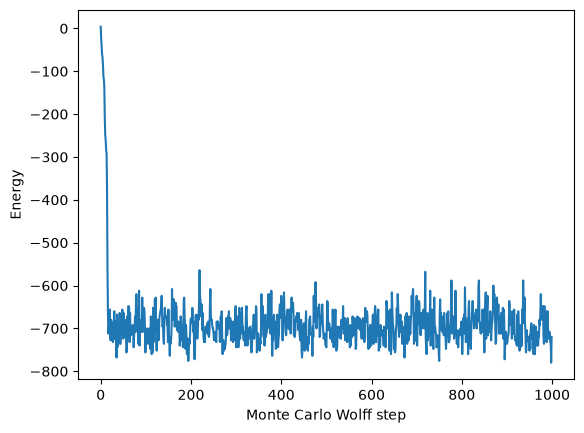

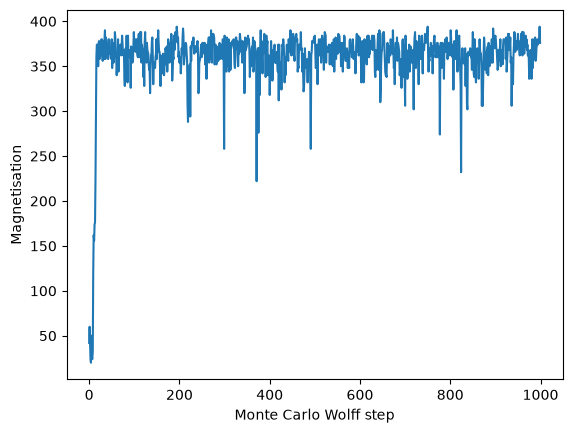

T=2.005 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.0307692307692307, we have 400


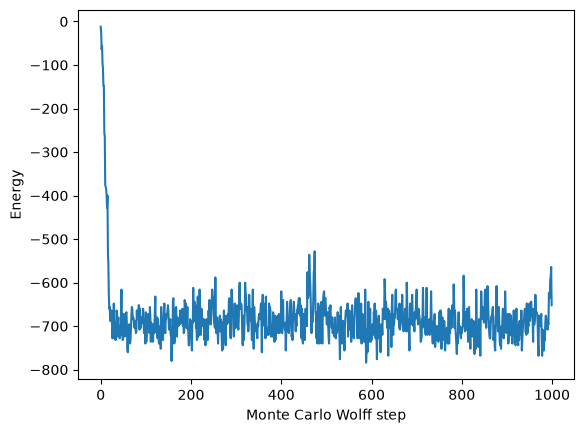

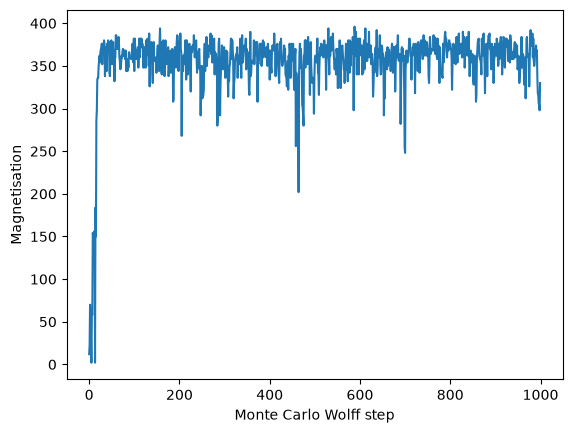

T=2.031 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.056410256410256, we have 400


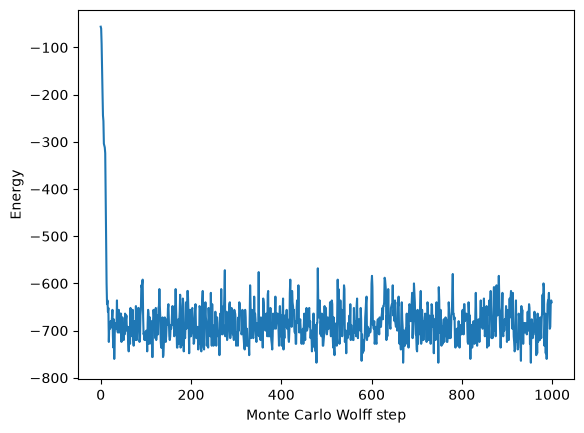

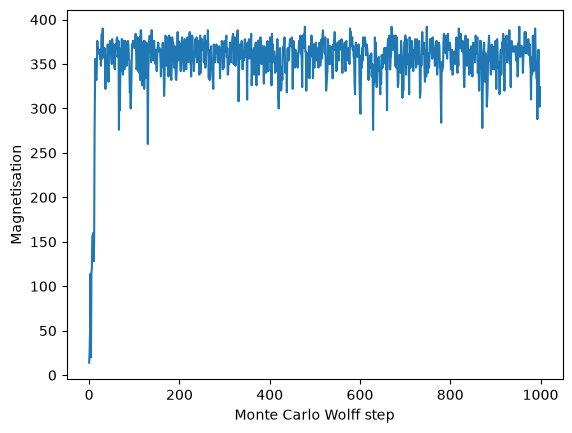

T=2.056 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.082051282051282, we have 400


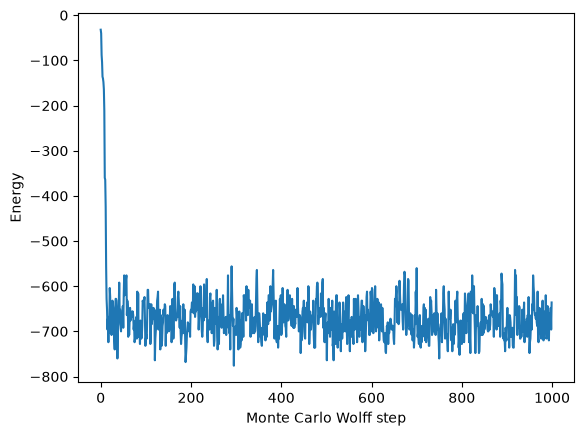

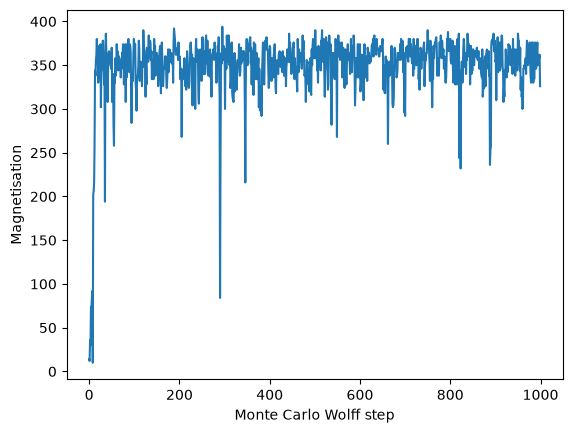

T=2.082 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.1076923076923078, we have 400


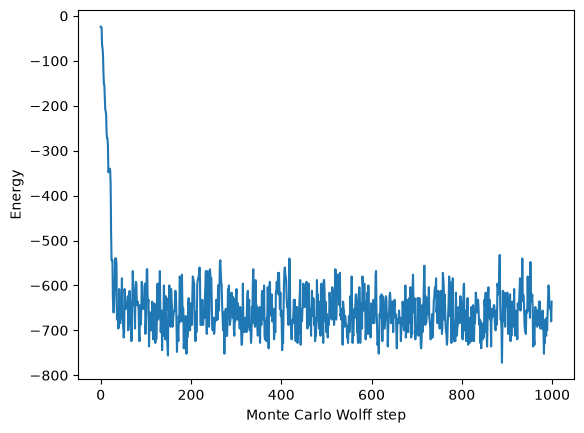

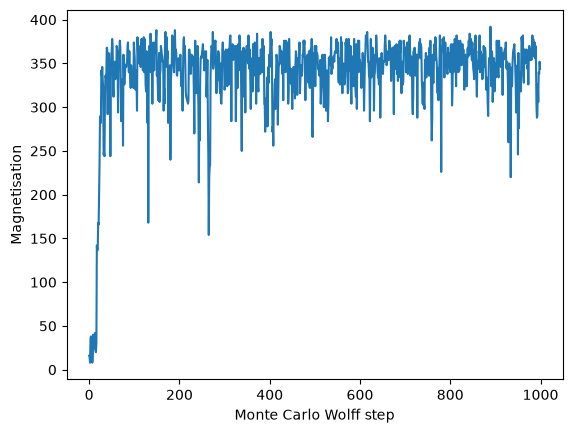

T=2.108 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.1333333333333333, we have 400


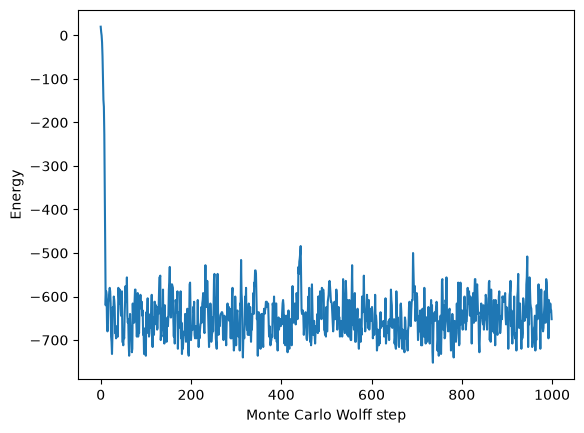

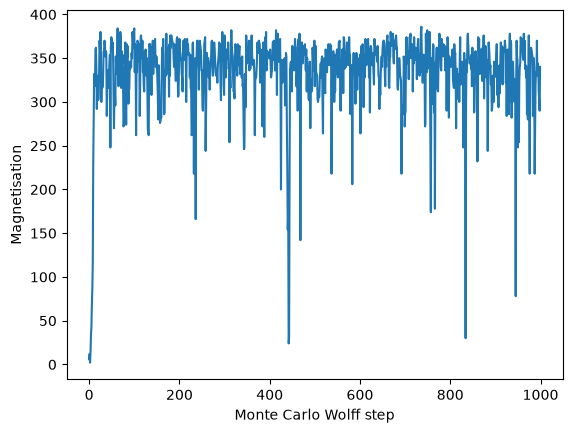

T=2.133 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.158974358974359, we have 400


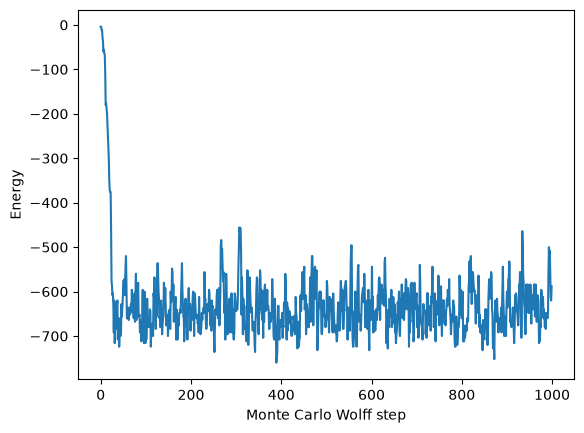

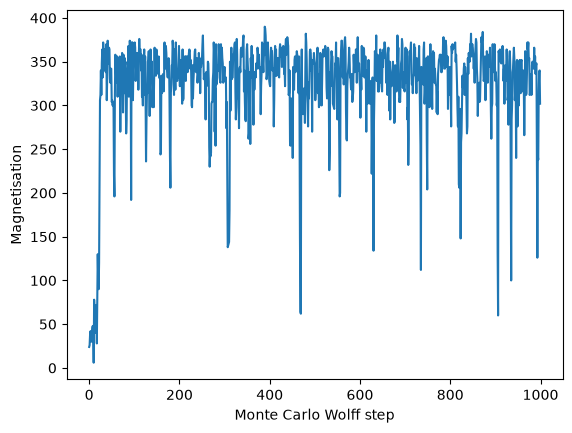

T=2.159 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.1846153846153844, we have 400


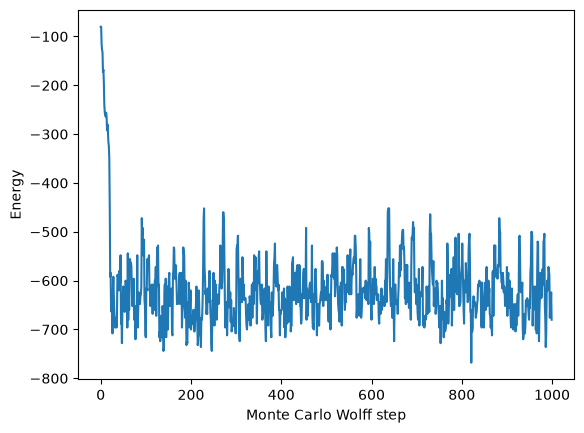

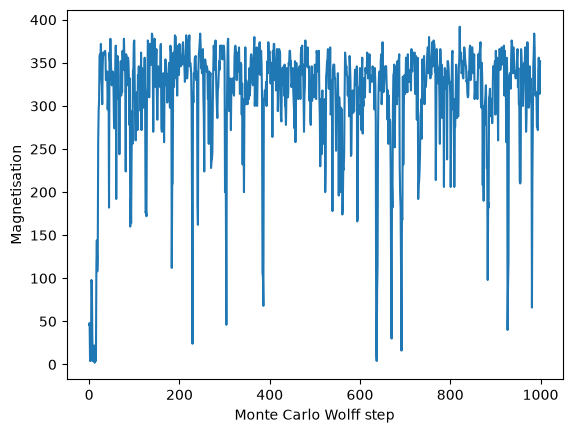

T=2.185 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.2102564102564104, we have 400


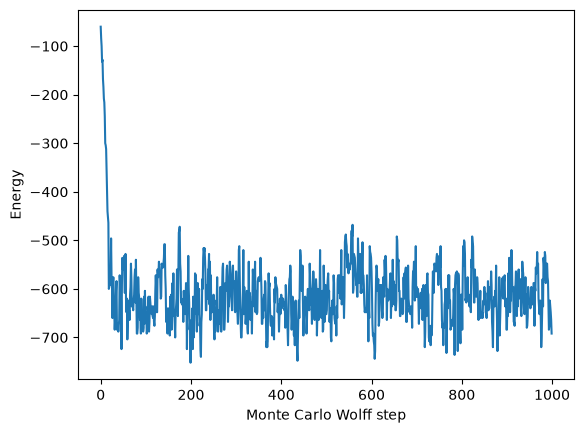

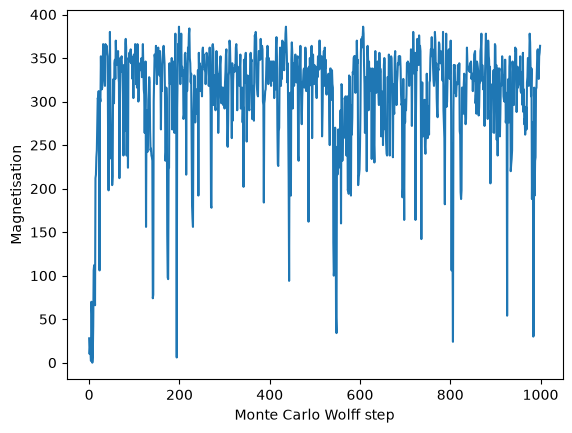

T=2.210 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.235897435897436, we have 400


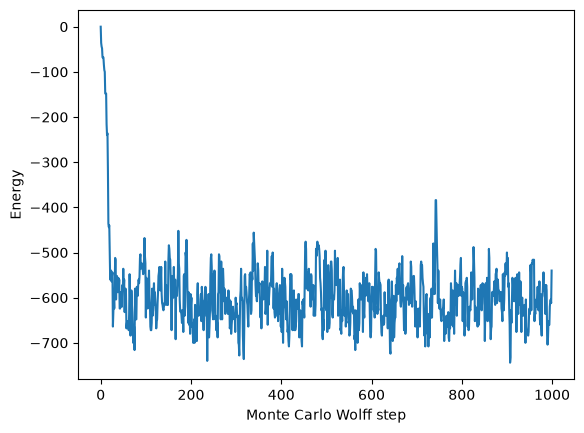

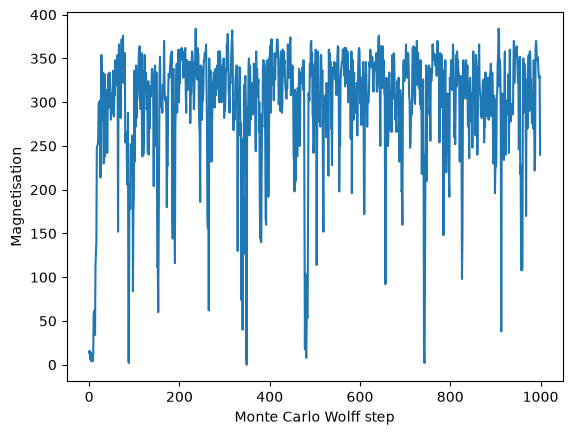

T=2.236 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.2615384615384615, we have 400


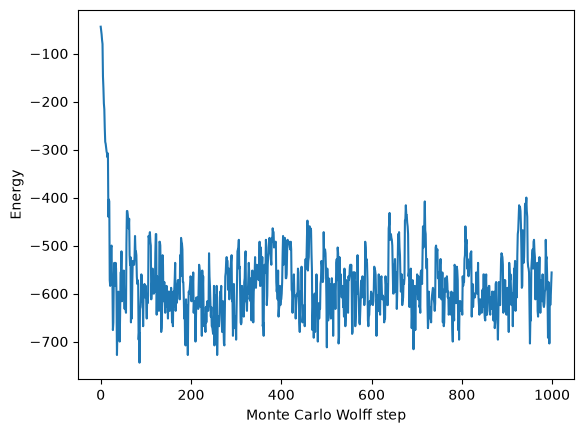

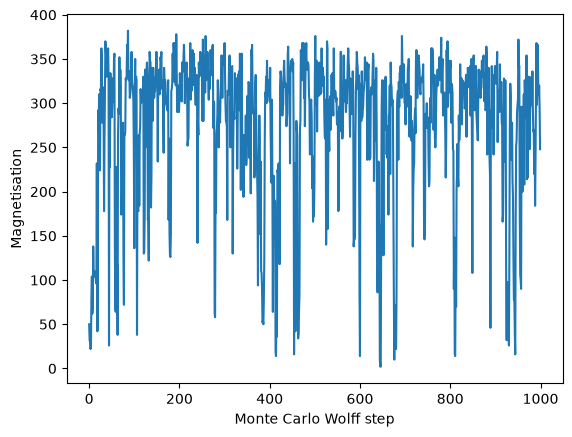

T=2.262 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.287179487179487, we have 400


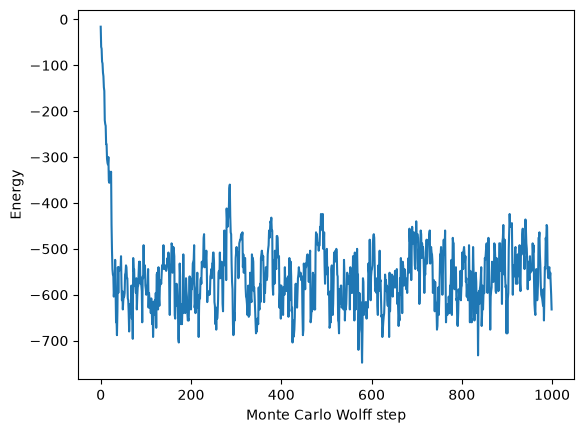

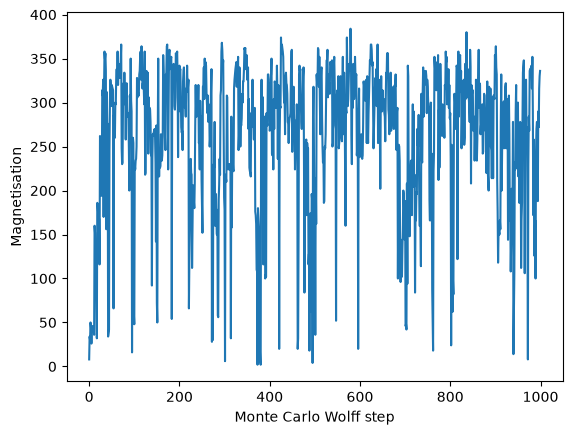

T=2.287 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.3128205128205126, we have 400


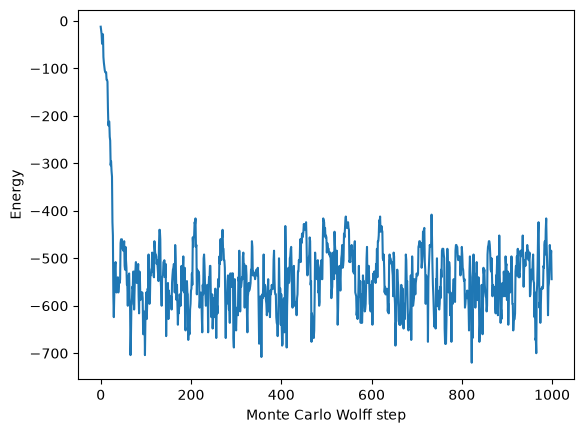

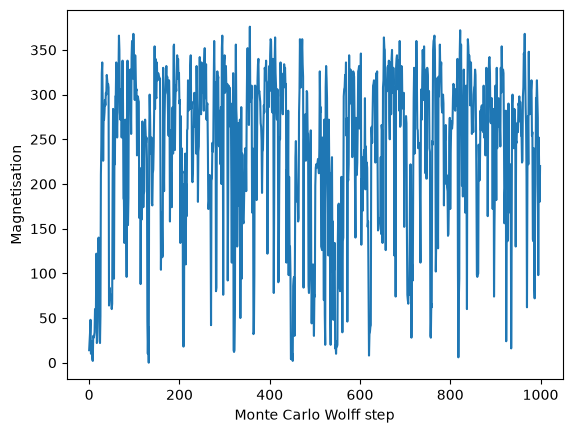

T=2.313 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.338461538461538, we have 400


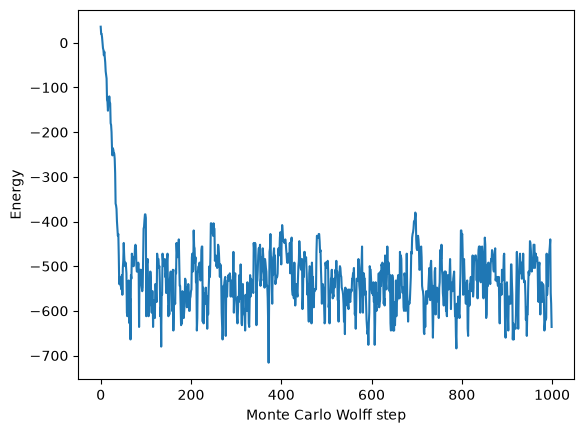

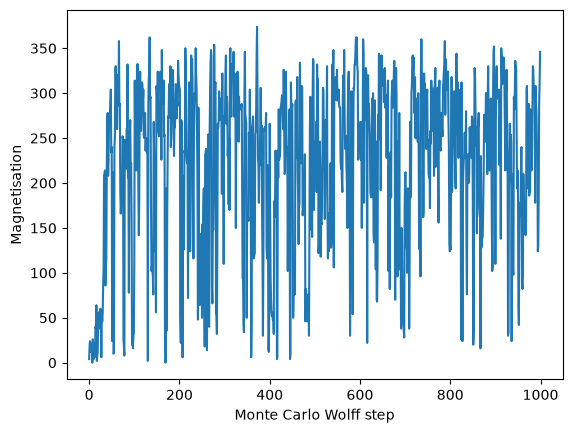

T=2.338 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.364102564102564, we have 400


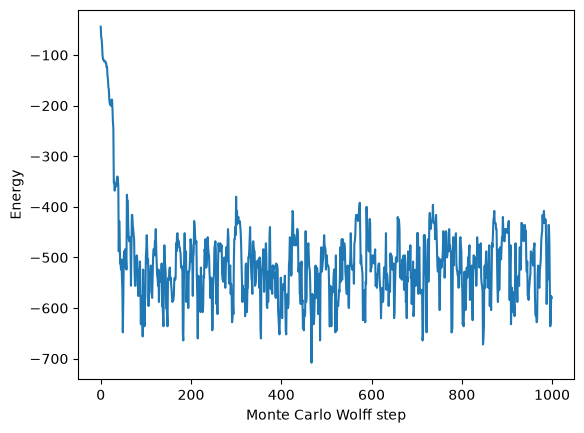

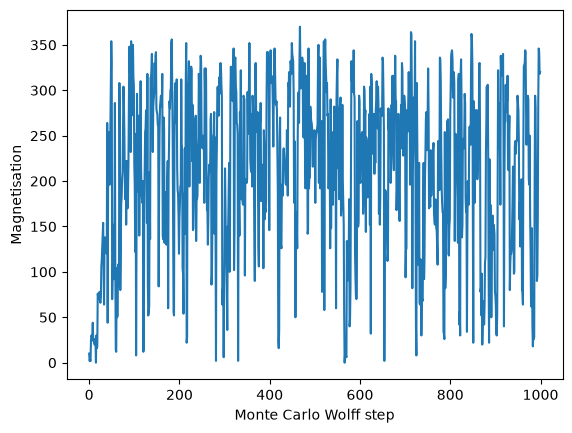

T=2.364 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.3897435897435897, we have 400


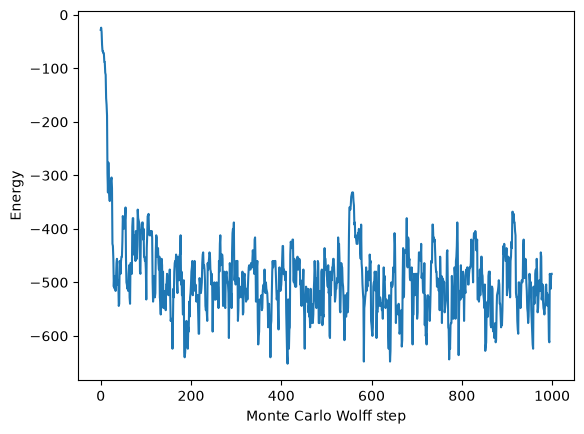

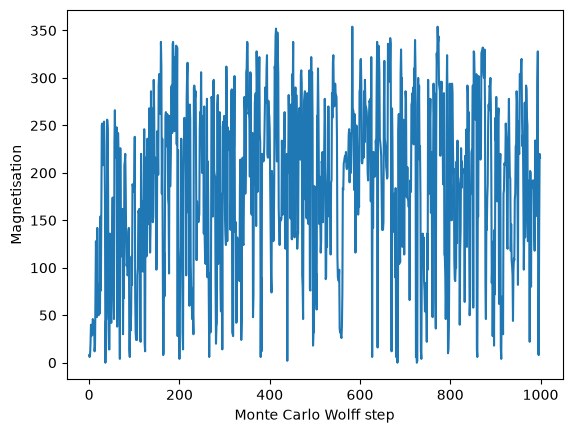

T=2.390 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.4153846153846152, we have 400


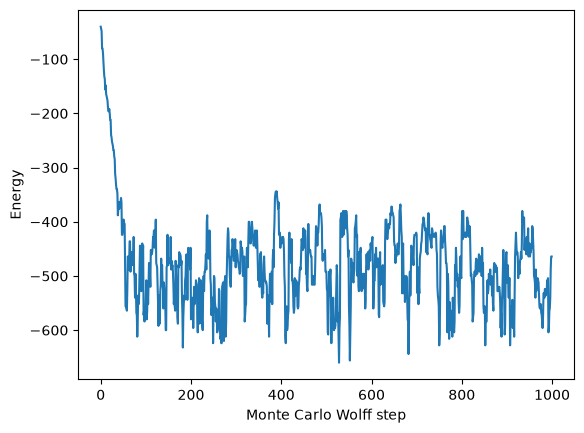

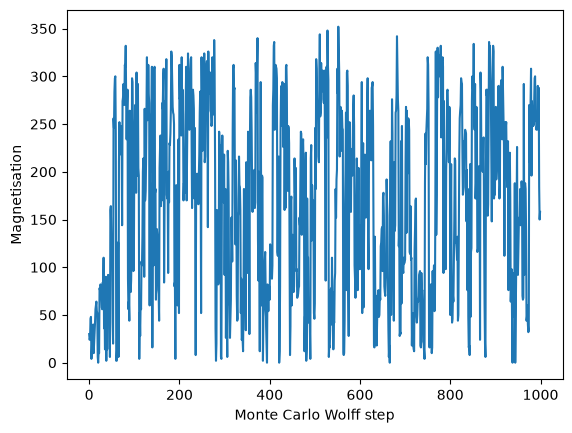

T=2.415 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.4410256410256412, we have 400


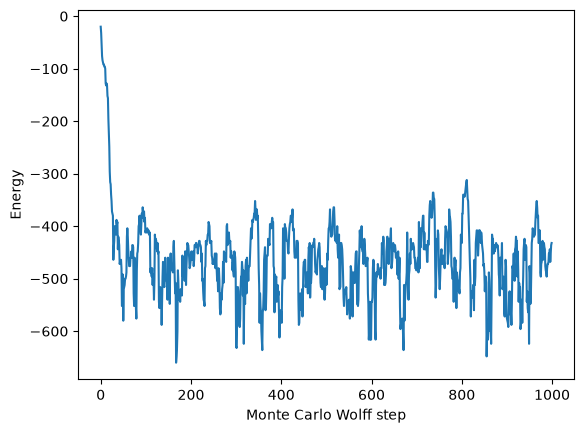

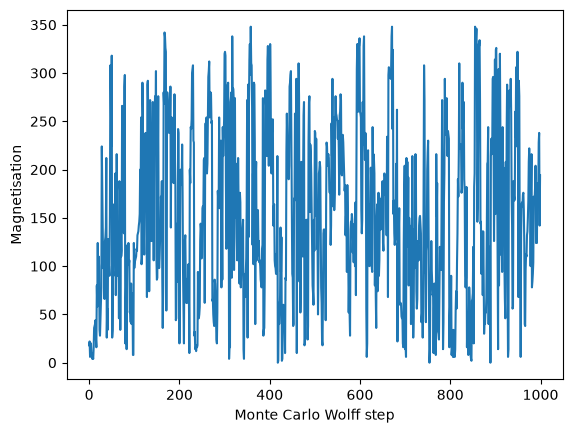

T=2.441 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.466666666666667, we have 400


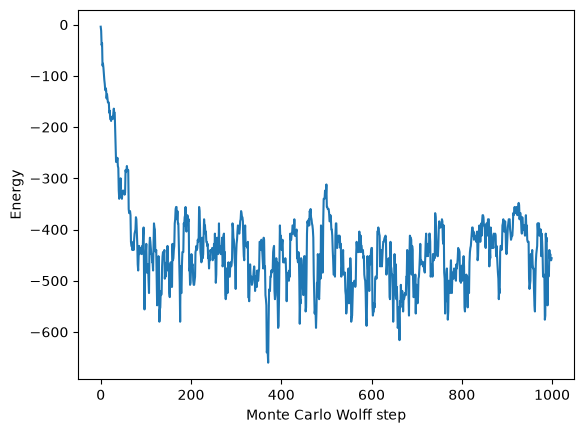

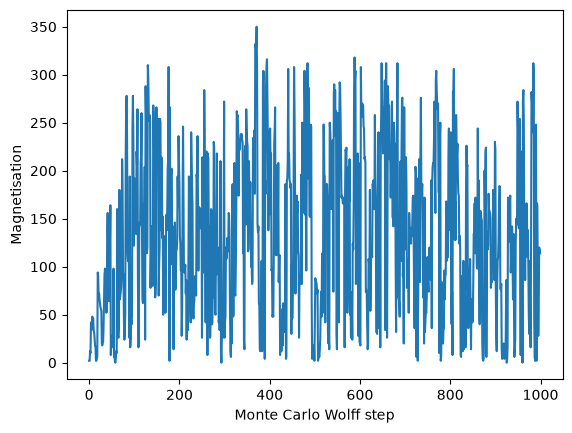

T=2.467 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.4923076923076923, we have 400


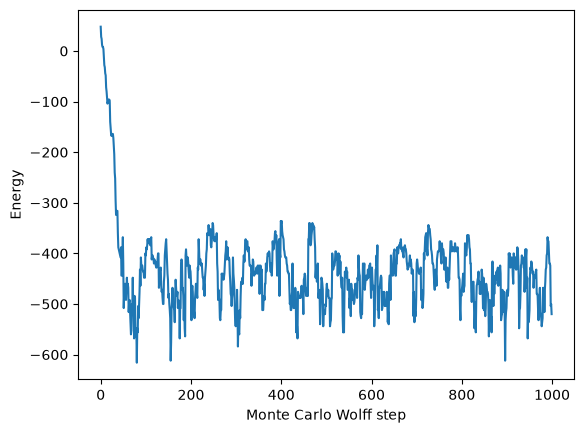

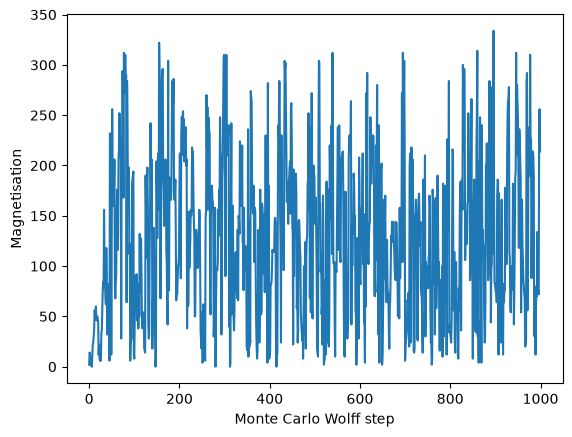

T=2.492 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.517948717948718, we have 400


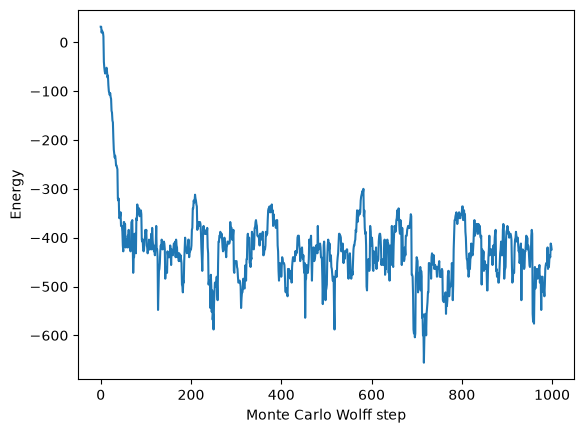

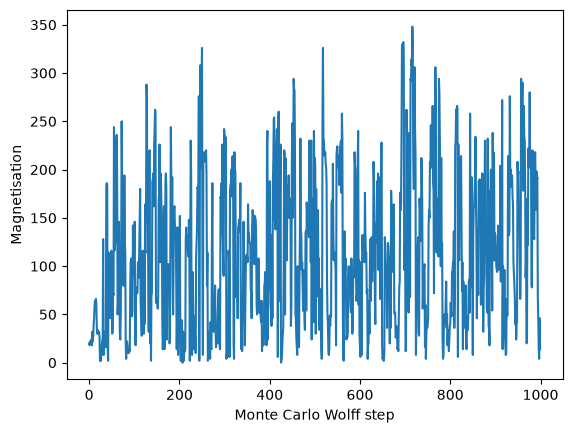

T=2.518 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.5435897435897434, we have 400


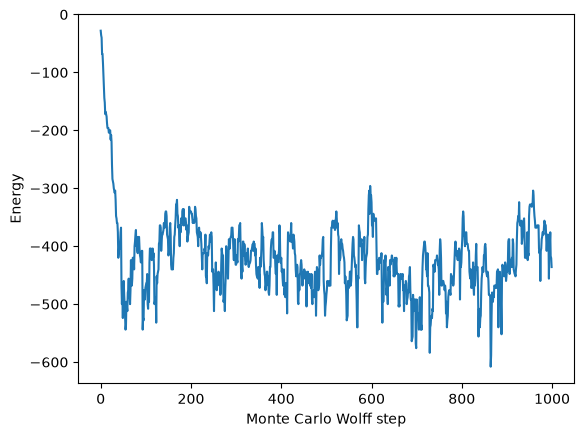

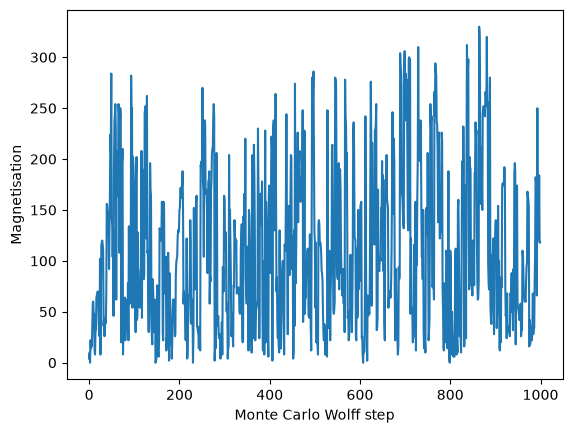

T=2.544 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.569230769230769, we have 400


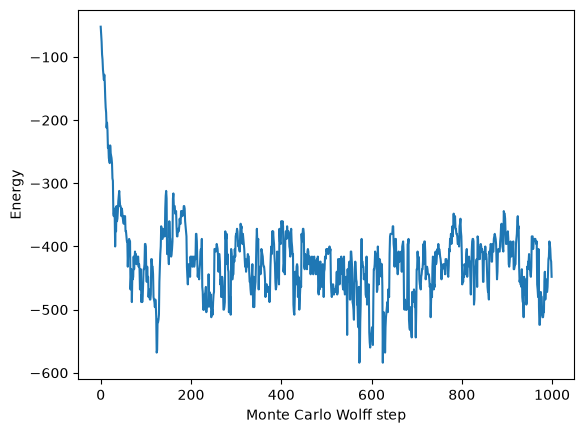

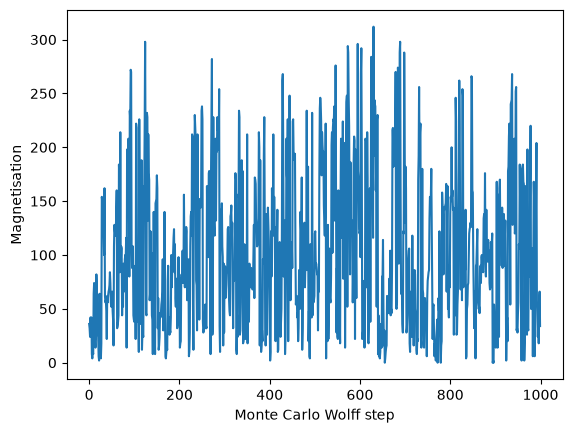

T=2.569 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.5948717948717945, we have 400


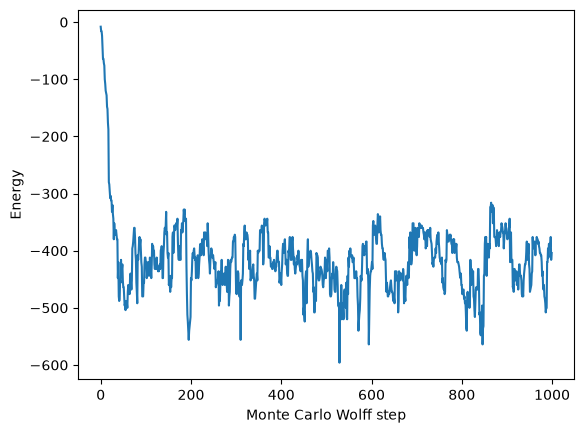

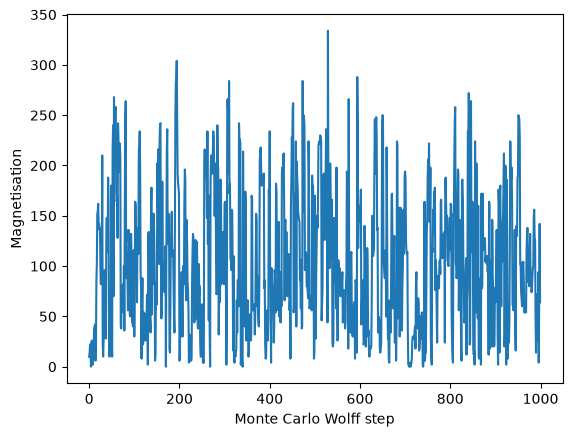

T=2.595 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.6205128205128205, we have 400


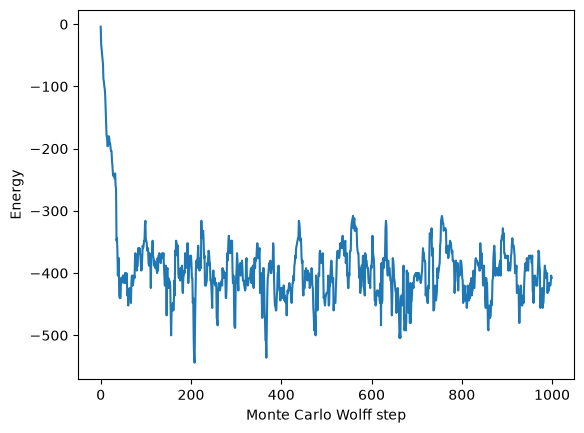

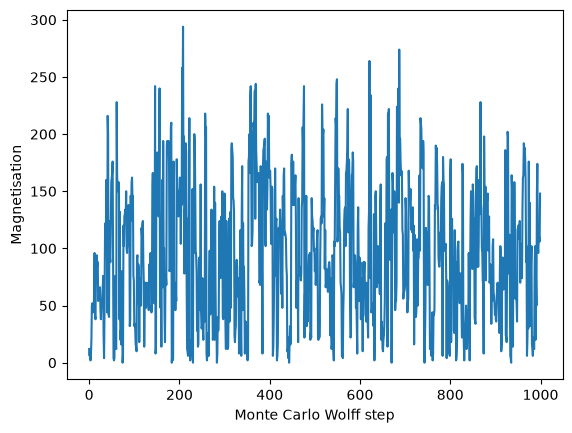

T=2.621 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.646153846153846, we have 400


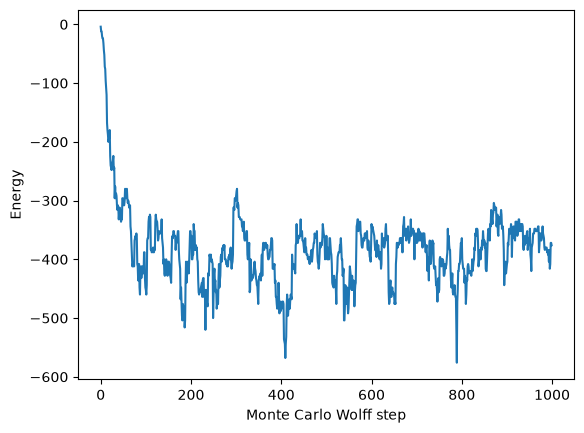

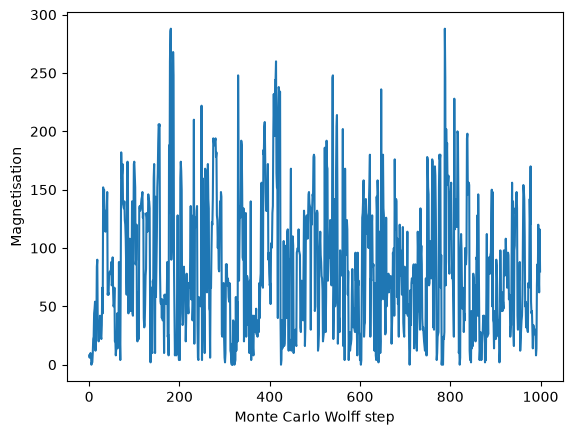

T=2.646 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.6717948717948716, we have 400


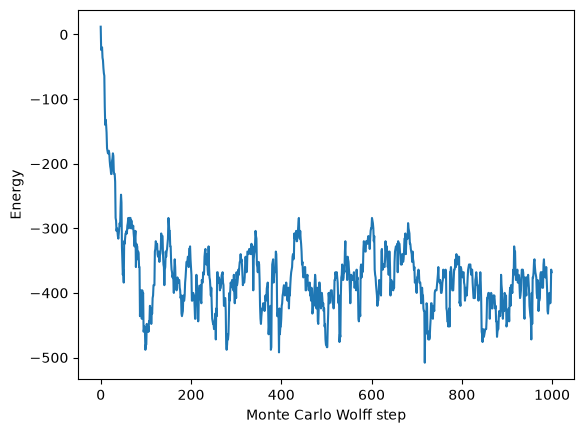

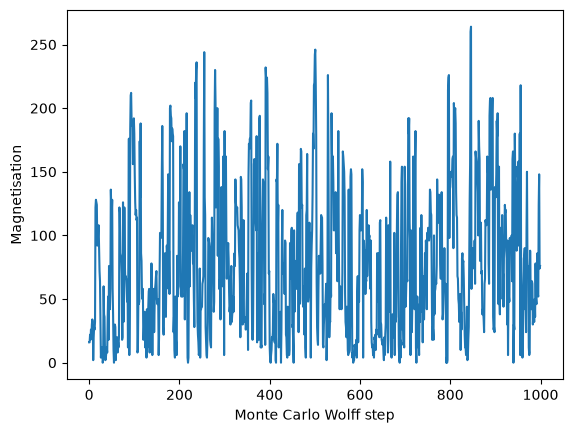

T=2.672 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.697435897435897, we have 400


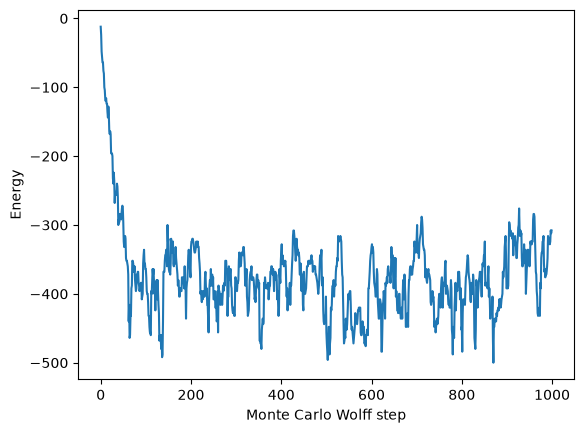

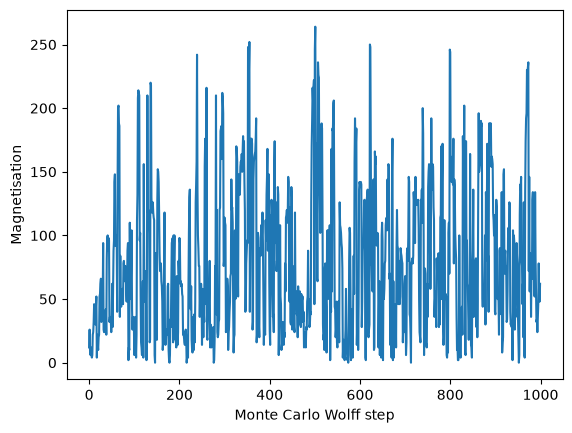

T=2.697 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.723076923076923, we have 400


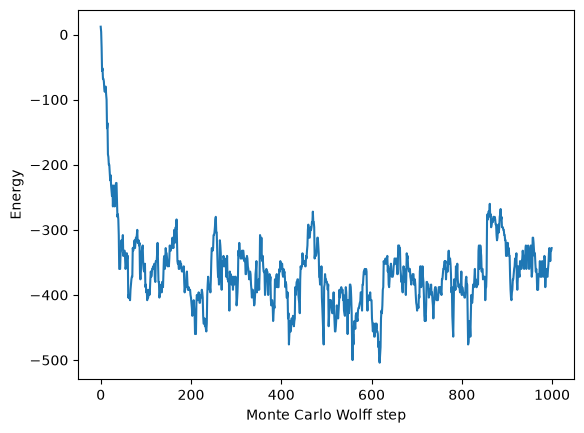

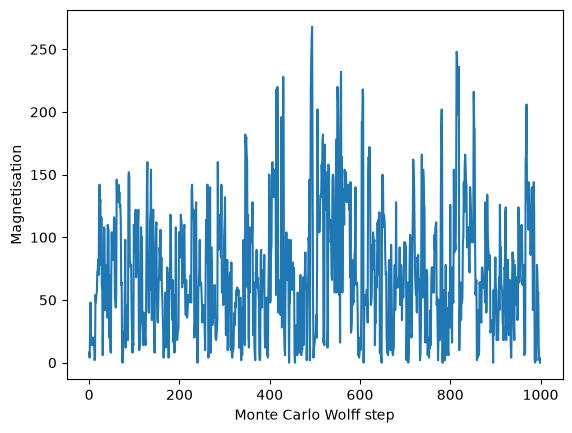

T=2.723 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.7487179487179487, we have 400


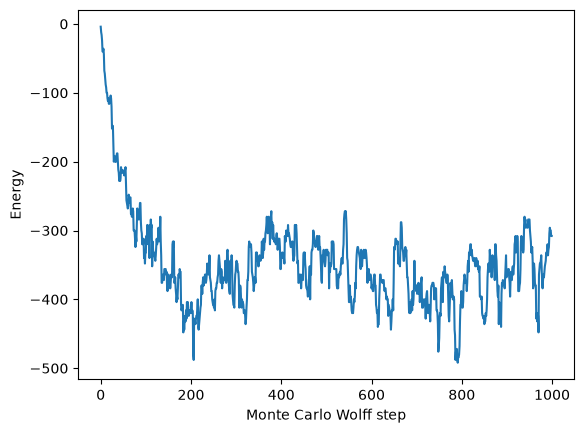

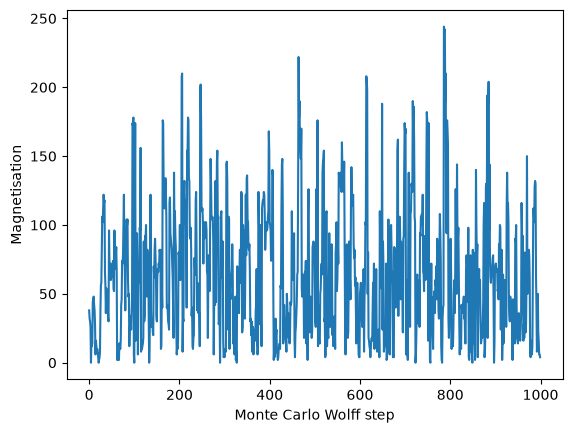

T=2.749 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.7743589743589743, we have 400


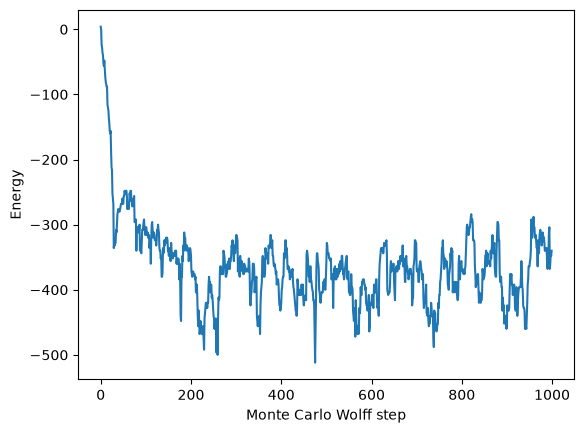

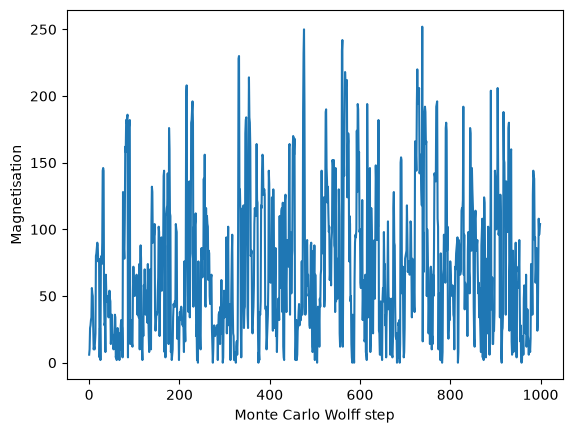

T=2.774 done, ran 50 runs x 1000 samples
Checking our warmup paramters make sense
At T= 2.8, we have 400


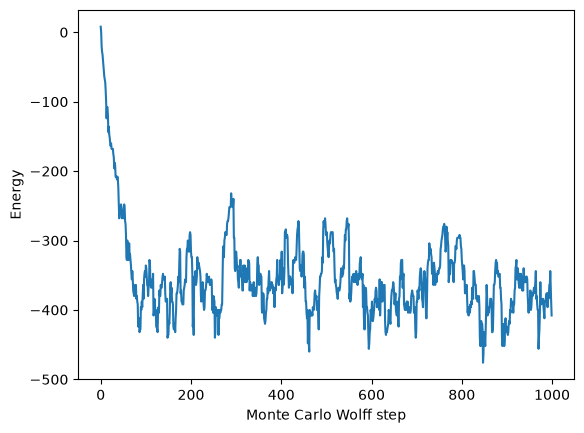

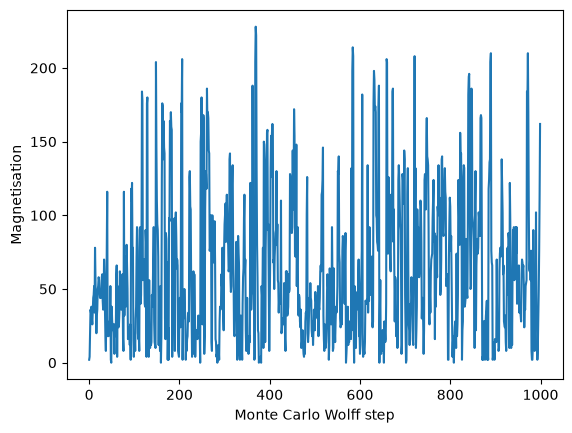

T=2.800 done, ran 50 runs x 1000 samples


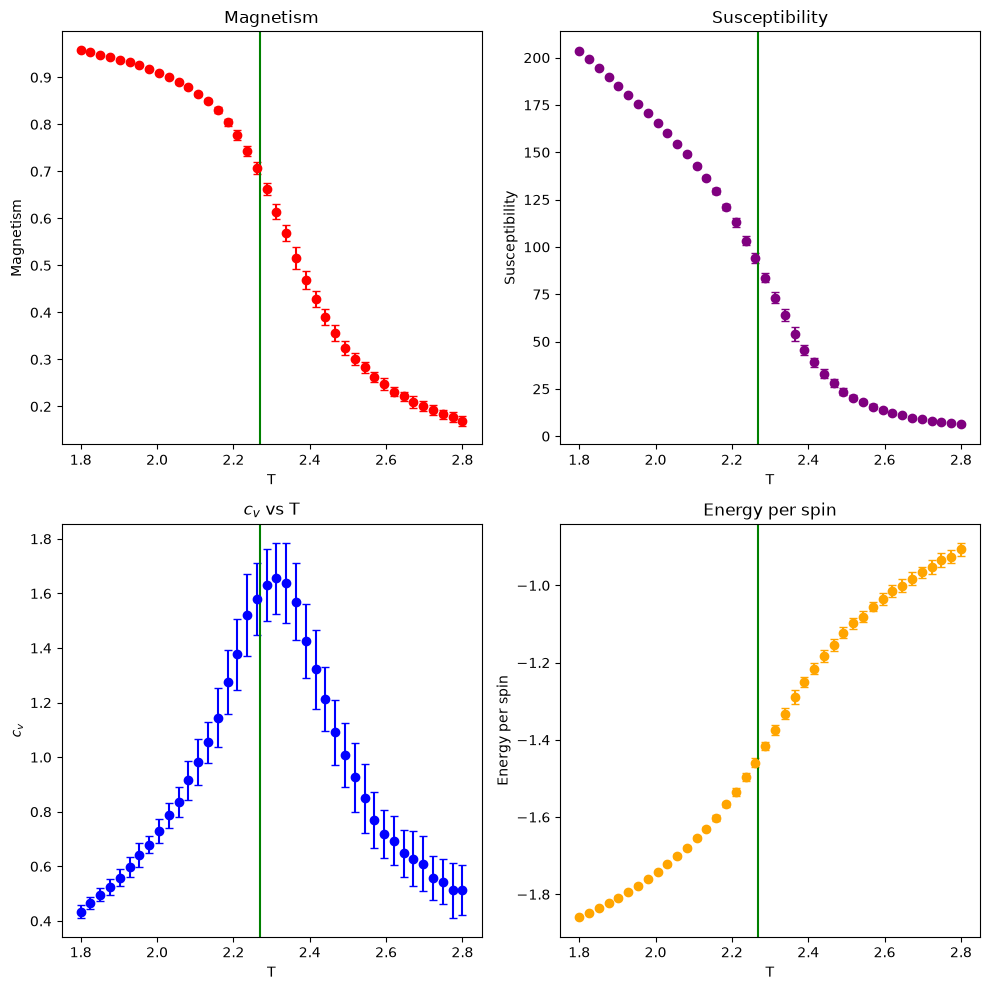

In [ ]:
#results = wolff_sim(L=20, temps=np.linspace(1.8, 2.8, 40),n_runs=50)

I think these mags plots show us that above $T_c$ we need more `warmup`  